In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install datasets

In [3]:
import sys
!{sys.executable} -m pip install datasets

In [4]:
from datasets import load_dataset

In [5]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [6]:
label_names = emotion_dataset['train'].features['label'].names

In [7]:
df_train = pd.DataFrame(
    {
    'text' : train_text,
    'label' : [label_names[i] for i in train_label]
    }
)
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [8]:
df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [9]:
label_names = emotion_dataset['train'].features['label'].names

In [10]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [11]:
for i in train_label:
    print(label_names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [12]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

In [13]:
df_test.isnull().sum()

text     0
label    0
dtype: int64

# EDA


visualizing class distribution across six emotions

<Axes: xlabel='label', ylabel='count'>

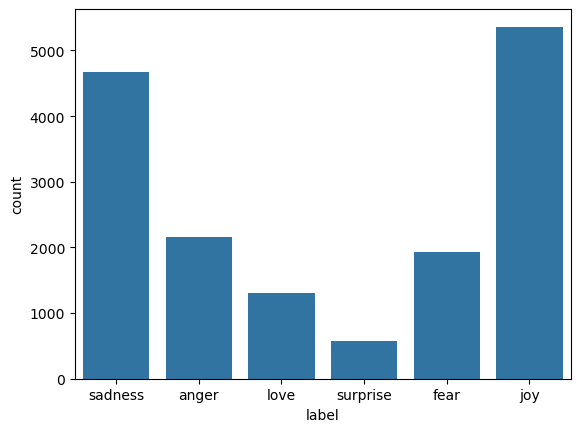

In [14]:
sns.countplot(x='label', data=df_train)

In [15]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

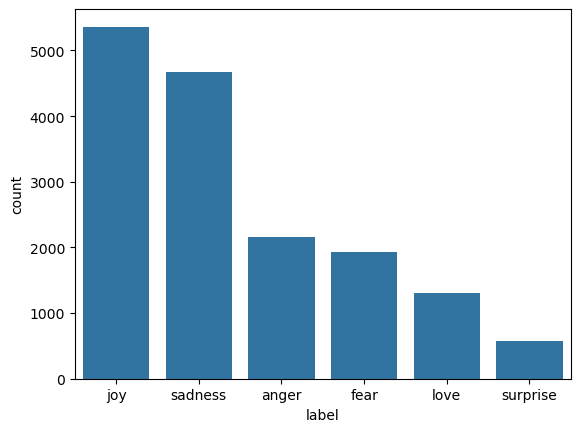

In [16]:
sns.countplot(x='label', data=df_train, order = df_train['label'].value_counts().index)

In [17]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


# Data Preprocessing using NLP

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_seq = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_seq = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_seq.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


# Shared Training Utilies

compute balanced class weights to handle dataset skew and setup early stopping

In [19]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
        monitor = 'val_loss',
        patience = 3,
        restore_best_weights=True
)

# Phase 1 - Plain Foundational Model

Simple RNN, Standard LSTM and standard GRU models

## Model 1 - Simple RNN

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

In [23]:
rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

C:\Users\aviba\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
rnn_model.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padded_test_seq, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_seq, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 122ms/step - accuracy: 0.1621 - loss: 1.8948 - val_accuracy: 0.1270 - val_loss: 1.8076
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 136ms/step - accuracy: 0.1616 - loss: 1.7988 - val_accuracy: 0.1555 - val_loss: 1.7828
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.1529 - loss: 1.7786 - val_accuracy: 0.0990 - val_loss: 1.7952
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.1674 - loss: 1.7668 - val_accuracy: 0.1530 - val_loss: 1.7688
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 138ms/step - accuracy: 0.1627 - loss: 1.7496 - val_accuracy: 0.1325 - val_loss: 1.7879
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54544s 109s/step - accuracy: 0.1611 - loss: 1.7414 - val_accuracy: 0.0700 - val_loss: 1.8651
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - accuracy: 0.1704 - loss: 1.7187 - val_accuracy: 0.1250 - val_loss: 1.8019
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1530 - loss: 1.7688
RNN Loss

## Model 2 - Standard LSTM
### Plain Stacked Long Short Term Memory Network

In [27]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padded_test_seq, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_seq, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 150s 285ms/step - accuracy: 0.1461 - loss: 1.7950 - val_accuracy: 0.0830 - val_loss: 1.7906
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 155s 311ms/step - accuracy: 0.1459 - loss: 1.7930 - val_accuracy: 0.1570 - val_loss: 1.7853
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 295ms/step - accuracy: 0.1708 - loss: 1.7673 - val_accuracy: 0.1790 - val_loss: 1.7459
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 123s 246ms/step - accuracy: 0.3119 - loss: 1.5474 - val_accuracy: 0.3170 - val_loss: 1.3422
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 128s 219ms/step - accuracy: 0.5145 - loss: 1.0542 - val_accuracy: 0.7715 - val_loss: 0.7832
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.6729 - loss: 0.6612 - val_accuracy: 0.4830 - val_loss: 1.0863
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.7376 - loss: 0.5213 - val_accuracy: 0.5990 - val_loss: 0.8326
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.8557 - lo

# Model 3 - Standard GRU

### Plain stacked Gated Recurrent Unit Network

In [30]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padded_test_seq, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_seq, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 72ms/step - accuracy: 0.1509 - loss: 1.7972 - val_accuracy: 0.0330 - val_loss: 1.8120
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.1490 - loss: 1.7950 - val_accuracy: 0.3475 - val_loss: 1.7733
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.1545 - loss: 1.7945 - val_accuracy: 0.1125 - val_loss: 1.7985
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 72ms/step - accuracy: 0.1507 - loss: 1.7929 - val_accuracy: 0.3430 - val_loss: 1.7490
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 73ms/step - accuracy: 0.1367 - loss: 1.7921 - val_accuracy: 0.1210 - val_loss: 1.7695
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.1596 - loss: 1.7800 - val_accuracy: 0.3175 - val_loss: 1.7636
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.1746 - loss: 1.7540 - val_accuracy: 0.1330 - val_loss: 1.8248
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3430 - loss: 1.7490
GRU Loss: 1.7490

# Ranking and Selection of Model

In [31]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.350793,0.9005
2,GRU,1.749047,0.3430
0,RNN,1.768760,0.1530


## Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

## Model 4 - Advanced Stacked Bidirectional GRU

In [32]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

C:\Users\aviba\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train and evaluate advanced bidirectional GRU

In [34]:
BiGRU.fit(
    padded_train_seq,
    train_labels,
    validation_data=(padded_test_seq, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 101ms/step - accuracy: 0.5488 - loss: 1.0079 - val_accuracy: 0.8730 - val_loss: 0.4492
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 48s 96ms/step - accuracy: 0.9076 - loss: 0.2680 - val_accuracy: 0.9065 - val_loss: 0.2926
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.9384 - loss: 0.1649 - val_accuracy: 0.9100 - val_loss: 0.2601
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.9551 - loss: 0.1192 - val_accuracy: 0.9245 - val_loss: 0.2411
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.9659 - loss: 0.0957 - val_accuracy: 0.9170 - val_loss: 0.2565
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.9724 - loss: 0.0792 - val_accuracy: 0.9185 - val_loss: 0.2760
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.9790 - loss: 0.0616 - val_accuracy: 0.9170 - val_loss: 0.3006


In [35]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_seq, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9245 - loss: 0.2411
BiGRU Loss: 0.2410656362771988
BiGRU Accuracy: 0.9244999885559082


# Overall Evaluation & Bias Analysis
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

###  Final Model Confusion Matrices (Raw Counts & Normalized %)

In [36]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


<Axes: >

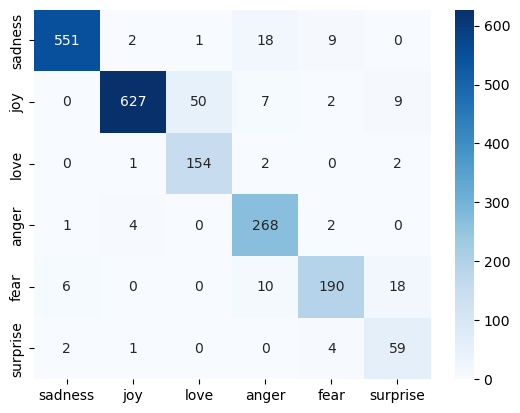

In [38]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_seq),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

# Final Prediction

Test the winning model on unseen sample sentences.

In [39]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


# Saving model and tokenizer

Export trained model and tokenizer artifacts for API deployment.

In [40]:

import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)